# Ollama Vision Playground\nTest llava:13b against Garmin screenshots before running the full ingestion pipeline.

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import base64
import hashlib
import json
import re
from IPython.display import Image, display

import httpx
import duckdb

from config.settings import DB_PATH, DROP_FOLDER, OLLAMA_VISION_MODEL

OLLAMA_URL = "http://localhost:11434/api/chat"
PROCESSED_DIR = DROP_FOLDER / "processed"

print(f"Model : {OLLAMA_VISION_MODEL}")
print(f"DB    : {DB_PATH}")
print(f"Drop  : {DROP_FOLDER}")

Model : qwen3-vl:latest
DB    : /Users/vvv/Projects/groundhog/data/db/groundhog.duckdb
Drop  : /Users/vvv/Projects/groundhog/data/drop


## 1. Pick an image\nSet `IMAGE_PATH` to any file you want to test against.

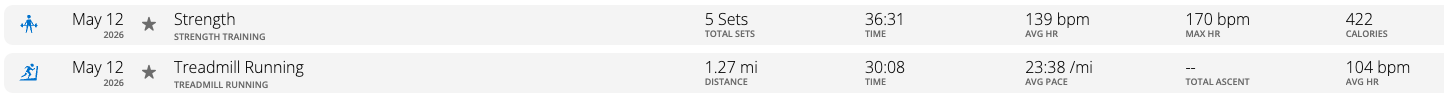

In [11]:
# --- change this to the image you want to test ---
IMAGE_PATH = DROP_FOLDER / "Screenshot 2026-05-12 at 8.07.07 PM.png"
# IMAGE_PATH = Path("/absolute/path/to/image.jpg")

display(Image(filename=str(IMAGE_PATH)))

## 2. Edit the prompt\nTweak and re-run this cell to experiment with different instructions.

In [12]:
PROMPT = """You are extracting data from a Garmin fitness tracker screenshot.

First, decide which type of screen this is:
- ACTIVITY screen: shows one or more activity entries — each with its duration (time or total time), avg HR, calories.
- DAILY SUMMARY screen: shows a single summary for the whole day — total steps, active minutes, resting heart rate. No individual workout entries.

If this is an ACTIVITY screen, return a JSON array with one object per activity.
Extract ONLY the metrics shown on that specific activity's own row — do not share or copy values across activities.
Convert any duration shown as h:mm:ss or mm:ss to total seconds (e.g. "1:17:50" → 4670).

[
  {
    "type": "activity",
    "date": "YYYY-MM-DD",
    "activity_type": <"running", "walking", "cycling", or similar>,
    "distance_miles": <float or null>,
    "duration_seconds": <integer or null>,
    "avg_pace_seconds_per_mile": <integer or null>,
    "avg_hr": <integer or null>,
    "max_hr": <integer or null>,
    "calories": <integer or null>
  }
]

If this is a DAILY SUMMARY screen, return a single JSON object:
{
  "type": "daily_summary",
  "date": "YYYY-MM-DD",
  "steps": <integer or null>,
  "avg_hr": <integer or null>,
  "active_minutes": <integer or null>
}

Use the date shown in the screenshot. Return null for any metric not visible. No explanation, just JSON."""

print(PROMPT)

You are extracting data from a Garmin fitness tracker screenshot.

First, decide which type of screen this is:
- ACTIVITY screen: shows one or more activity entries — each with its duration (time or total time), avg HR, calories.
- DAILY SUMMARY screen: shows a single summary for the whole day — total steps, active minutes, resting heart rate. No individual workout entries.

If this is an ACTIVITY screen, return a JSON array with one object per activity.
Extract ONLY the metrics shown on that specific activity's own row — do not share or copy values across activities.
Convert any duration shown as h:mm:ss or mm:ss to total seconds (e.g. "1:17:50" → 4670).

[
  {
    "type": "activity",
    "date": "YYYY-MM-DD",
    "activity_type": <"running", "walking", "cycling", or similar>,
    "distance_miles": <float or null>,
    "duration_seconds": <integer or null>,
    "avg_pace_seconds_per_mile": <integer or null>,
    "avg_hr": <integer or null>,
    "max_hr": <integer or null>,
    "calori

## 3. Send to Ollama — raw response

In [13]:
encoded = base64.b64encode(IMAGE_PATH.read_bytes()).decode("utf-8")

payload = {
    "model": OLLAMA_VISION_MODEL,
    "messages": [
        {
            "role": "user",
            "content": PROMPT,
            "images": [encoded],
        }
    ],
    "stream": False,
}

response = httpx.post(OLLAMA_URL, json=payload, timeout=120.0)
#response.raise_for_status()
print(response.text)

raw = response.json()["message"]["content"]
print(raw)

{"model":"qwen3-vl:latest","created_at":"2026-05-13T03:10:25.232472Z","message":{"role":"assistant","content":"[\n  {\n    \"type\": \"activity\",\n    \"date\": \"2025-05-12\",\n    \"activity_type\": \"strength\",\n    \"distance_miles\": null,\n    \"duration_seconds\": 2191,\n    \"avg_pace_seconds_per_mile\": null,\n    \"avg_hr\": 139,\n    \"max_hr\": 170,\n    \"calories\": 422\n  },\n  {\n    \"type\": \"activity\",\n    \"date\": \"2025-05-12\",\n    \"activity_type\": \"running\",\n    \"distance_miles\": 1.27,\n    \"duration_seconds\": 1808,\n    \"avg_pace_seconds_per_mile\": 1418,\n    \"avg_hr\": 104,\n    \"max_hr\": null,\n    \"calories\": null\n  }\n]","thinking":"Got it, let's analyze the screenshot. First, check if it's an ACTIVITY screen or DAILY SUMMARY. The screenshot has two entries: \"Strength\" and \"Treadmill Running\", each with their own details. So it's an ACTIVITY screen with multiple activities.\n\nNow, for each activity, extract the metrics.\n\nFirst 

## 4. Parse response

In [14]:
def parse_metrics(raw: str):
    match = re.search(r"(\[.*?\]|\{.*?\})", raw, re.DOTALL)
    if not match:
        print("No JSON found in response.")
        return None
    try:
        parsed = json.loads(match.group())
        return parsed if isinstance(parsed, list) else [parsed]
    except json.JSONDecodeError as e:
        print(f"JSON parse error: {e}")
        return None

records = parse_metrics(raw)
records

[{'type': 'activity',
  'date': '2025-05-12',
  'activity_type': 'strength',
  'distance_miles': None,
  'duration_seconds': 2191,
  'avg_pace_seconds_per_mile': None,
  'avg_hr': 139,
  'max_hr': 170,
  'calories': 422},
 {'type': 'activity',
  'date': '2025-05-12',
  'activity_type': 'running',
  'distance_miles': 1.27,
  'duration_seconds': 1808,
  'avg_pace_seconds_per_mile': 1418,
  'avg_hr': 104,
  'max_hr': None,
  'calories': None}]

## 5. Insert into DuckDB (optional)\nOnly run this cell when you're happy with the parsed output.

In [ ]:
def activity_id(date, activity_type, duration_seconds):
    key = f"{date}|{activity_type}|{duration_seconds}"
    return hashlib.sha256(key.encode()).hexdigest()[:16]

con = duckdb.connect(str(DB_PATH))

for metrics in (records or []):
    record_type = metrics.get("type")
    if record_type == "daily_summary":
        con.execute(
            """
            INSERT INTO health_metrics (date, steps, avg_hr, active_minutes)
            VALUES (?, ?, ?, ?)
            ON CONFLICT (date) DO NOTHING
            """,
            [metrics["date"], metrics.get("steps"), metrics.get("avg_hr"), metrics.get("active_minutes")],
        )
        print(f"Inserted daily_summary: {metrics}")
    elif record_type == "activity":
        aid = activity_id(metrics["date"], metrics.get("activity_type", ""), metrics.get("duration_seconds"))
        con.execute(
            """
            INSERT INTO activities (
                id, date, activity_type, distance_miles, duration_seconds,
                avg_pace_seconds_per_mile, avg_hr, max_hr, calories
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
            ON CONFLICT (id) DO NOTHING
            """,
            [
                aid, metrics["date"], metrics.get("activity_type"), metrics.get("distance_miles"),
                metrics.get("duration_seconds"), metrics.get("avg_pace_seconds_per_mile"),
                metrics.get("avg_hr"), metrics.get("max_hr"), metrics.get("calories"),
            ],
        )
        print(f"Inserted activity ({aid}): {metrics}")
    else:
        print(f"Unknown type: {record_type}")

con.close()

## 5. Verify — query the DB

In [15]:
con = duckdb.connect(str(DB_PATH))
print("=== health_metrics ===")
display(con.execute("SELECT * FROM health_metrics ORDER BY date DESC LIMIT 10").fetchdf())
print("=== activities ===")
display(con.execute("SELECT * FROM activities ORDER BY date DESC LIMIT 10").fetchdf())
con.close()

=== health_metrics ===


,date,steps,avg_hr,active_minutes,created_at
0,2023-04-30,<NA>,<NA>,<NA>,2026-05-10 14:37:15.252280


=== activities ===


,id,date,activity_type,distance_miles,duration_seconds,avg_pace_seconds_per_mile,avg_hr,calories,created_at
0,9474b2f3b3280698,2026-05-11,walking,1.00,1220,1218,108,118,2026-05-12 19:43:56.073891
1,bff1bc0004e11524,2026-05-11,cardio,NaN,2100,<NA>,164,529,2026-05-12 19:43:56.082917
2,37a7ce5b31194e4b,2026-05-11,running,1.87,1801,965,130,<NA>,2026-05-12 19:43:56.084035
3,faf0b3fbc494d4c3,2025-05-12,strength training,NaN,2191,<NA>,139,422,2026-05-12 20:12:15.921873
4,cd5308e2826e5a16,2025-05-12,running,1.27,1808,1403,104,<NA>,2026-05-12 20:12:15.924473
5,ae895f24c3d552ad,2021-04-30,walking,9.75,11841,<NA>,129,320,2026-05-10 14:46:52.289514


In [ ]:
duckdb.connect(str(DB_PATH)).execute(""" delete from activities where date = '2025-05-12' """)